In [1]:
!pip -q install timm==1.0.9

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 47.8 MB/s eta 0:00:0000:01


In [ ]:
import os
import math
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from PIL import Image
import timm

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

COMPUTE_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {COMPUTE_DEVICE}")

Device: cuda


In [ ]:
# основний датасет
PRIMARY_DATASET_DIR = Path( "/kaggle/input/datasets/ebtesamalshemmary/brain-tumor-mri-classification")
TRAINING_IMAGES_DIR = PRIMARY_DATASET_DIR / "Training" / "Training"
TEST_IMAGES_DIR = PRIMARY_DATASET_DIR / "Testing"  / "Testing"

# зовнішній датасет для додаткової перевірки
EXTERNAL_DATASET_DIR = Path("/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri")
EXTERNAL_TEST_IMAGES_DIR = EXTERNAL_DATASET_DIR / "Testing"

OUTPUT_DIR = Path("/kaggle/working")
OUTPUT_DIR.mkdir(exist_ok=True)

CLASS_LABELS = ["glioma", "meningioma", "notumor", "pituitary"]
N_CLASSES = len(CLASS_LABELS)

EXTERNAL_LABEL_MAP = {
    "glioma_tumor":     0,
    "meningioma_tumor": 1,
    "no_tumor":         2,
    "pituitary_tumor":  3,
}

SWIN_BACKBONE_NAME = "swin_base_patch4_window7_224.ms_in22k_ft_in1k"
N_EPOCHS = 40
LEARNING_RATE = 3e-5
BATCH_SIZE = 32
IMAGE_SIZE = 224

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomVerticalFlip(0.2),
    transforms.RandomRotation(15),
    transforms.TrivialAugmentWide(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [ ]:
class ImagePathDataset(Dataset):
    def __init__(self, image_paths, image_labels, transform):
        self.image_paths = [str(p) for p in image_paths]
        self.image_labels = image_labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):

        image = Image.open(self.image_paths[index]).convert("RGB")
        image = self.transform(image)
        label = int(self.image_labels[index])

        return image, label


def load_image_paths(root_dir: Path, folder_map: dict):
    paths = []
    labels = []

    for folder_name, label_idx in folder_map.items():
        class_dir = root_dir / folder_name

        if not class_dir.exists():
            print(f"[WARNING] Not found: {class_dir}")
            continue

        files = sorted(
            f
            for ext in ("*.jpg", "*.jpeg", "*.png")
            for f in class_dir.rglob(ext)
        )

        paths.extend(files)
        labels.extend([label_idx] * len(files))

        print(f"  {folder_name}: {len(files)} images")

    return paths, np.asarray(labels, dtype=np.int64)

In [7]:
# завантаження датасетів
train_dataset = datasets.ImageFolder(str(TRAINING_IMAGES_DIR), transform=train_transform)
test_dataset = datasets.ImageFolder(str(TEST_IMAGES_DIR),      transform=val_transform)

external_paths, y_external = load_image_paths(EXTERNAL_TEST_IMAGES_DIR, EXTERNAL_LABEL_MAP)
external_dataset = ImagePathDataset(external_paths, y_external, val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
external_loader = DataLoader(external_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_loader)} batches")
print(f"Test: {len(test_loader)} batches")
print(f"External: {len(external_loader)} batches")

  glioma_tumor: 100 images
  meningioma_tumor: 115 images
  no_tumor: 105 images
  pituitary_tumor: 74 images
Train    : 1003 batches
Test     : 251 batches
External : 13 batches


In [ ]:
from kaggle_secrets import UserSecretsClient

user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("token")

os.environ["HF_TOKEN"] = hf_token
os.environ["HUGGINGFACE_HUB_TOKEN"] = hf_token

In [ ]:
class SwinBaselineClassifier(nn.Module):
    def __init__(self, num_classes: int = 4, dropout_rate: float = 0.1):
        super().__init__()

        # попередньо навчена Swin Transformer
        self.swin_backbone = timm.create_model(
            SWIN_BACKBONE_NAME,
            pretrained=True,
            num_classes=0,
            global_pool="avg",
        )

        swin_dim = self.swin_backbone.num_features

        self.head = nn.Sequential(
            nn.LayerNorm(swin_dim),
            nn.Dropout(dropout_rate),
            nn.Linear(swin_dim, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(self.swin_backbone(x))


model = SwinBaselineClassifier(num_classes=N_CLASSES).to(COMPUTE_DEVICE)


trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Parameters: {trainable:,} trainable / {total:,} total ({100*trainable/total:.1f}%)")

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Parameters: 86,749,372 trainable / 86,749,372 total (100.0%)


In [ ]:
#mixup аугментація
def mixup_data(images, labels, alpha=0.2):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(images.size(0), device=images.device)
    return lam * images + (1 - lam) * images[idx], labels, labels[idx], lam


def mixup_loss(criterion, preds, ya, yb, lam):
    return lam * criterion(preds, ya) + (1 - lam) * criterion(preds, yb)

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, scaler, scheduler):
    model.train()  

    total_loss = 0.0
    correct = 0
    n = 0

    for imgs, labels in tqdm(loader, leave=False, desc="train"):
        imgs = imgs.to(COMPUTE_DEVICE)
        labels = labels.to(COMPUTE_DEVICE)

        use_mix = random.random() < 0.5

        if use_mix:
            imgs, ya, yb, lam = mixup_data(imgs, labels)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=COMPUTE_DEVICE.type == "cuda"):
            logits = model(imgs)

            if use_mix:
                loss = mixup_loss(criterion, logits, ya, yb, lam)
            else:
                loss = criterion(logits, labels)

        scaler.scale(loss).backward()

        scaler.unscale_(optimizer)

        nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        scaler.step(optimizer)
        scaler.update()

        scheduler.step()


        preds = logits.argmax(1)

        total_loss += loss.item() * imgs.size(0)

        if use_mix:
            correct += (preds == ya).sum().item()
        else:
            correct += (preds == labels).sum().item()

        n += imgs.size(0)

    return total_loss / n, correct / n

#оцінка 
@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval() 

    total_loss = 0.0
    correct = 0
    n = 0

    all_preds = []
    all_labels = []
    all_probs = []

    for imgs, labels in tqdm(loader, leave=False, desc="eval"):

        imgs = imgs.to(COMPUTE_DEVICE)
        labels = labels.to(COMPUTE_DEVICE)

        with torch.cuda.amp.autocast(enabled=COMPUTE_DEVICE.type == "cuda"):
            logits = model(imgs)
            loss = criterion(logits, labels)

        probs = torch.softmax(logits, 1)

        preds = logits.argmax(1)

        total_loss += loss.item() * imgs.size(0)
        correct += (preds == labels).sum().item()
        n += imgs.size(0)
        
        all_preds.append(preds.cpu().numpy())
        all_labels.append(labels.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

    return (
        total_loss / n,
        correct / n,
        np.concatenate(all_preds),
        np.concatenate(all_labels),
        np.vstack(all_probs),
    )

In [ ]:
class EarlyStopping:
    def __init__(self, patience_loss=5, patience_acc=7, min_delta=1e-4,
                 gap_threshold=0.10, gap_window=5, gap_patience=3):
        self.patience_loss = patience_loss
        self.patience_acc = patience_acc
        self.min_delta = min_delta
        self.gap_threshold = gap_threshold
        self.gap_window = gap_window
        self.gap_patience = gap_patience

        self.best_loss = float("inf")
        self.best_acc = 0.0
        self.loss_cnt = 0
        self.acc_cnt = 0
        self.gap_hist = []
        self.stop = False
        self.reason = ""

    def step(self, val_loss, val_acc, train_acc) -> bool:
        if self.stop:
            return True
        
        # перевірка loss
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.loss_cnt  = 0
        else:
            self.loss_cnt += 1

        if self.loss_cnt >= self.patience_loss:
            self.stop = True
            self.reason = f"val-loss stagnated {self.patience_loss} epochs"
            return True
        
        # перевірка accuracy
        if val_acc > self.best_acc + self.min_delta:
            self.best_acc = val_acc
            self.acc_cnt  = 0
        else:
            self.acc_cnt += 1

        if self.acc_cnt >= self.patience_acc:
            self.stop = True
            self.reason = f"val-acc stagnated {self.patience_acc} epochs"
            return True
        
        # перевірка переначання
        gap = train_acc - val_acc
        self.gap_hist.append(gap > self.gap_threshold)
        if (len(self.gap_hist) >= self.gap_window and sum(self.gap_hist[-self.gap_window:]) >= self.gap_patience):
            self.stop = True
            self.reason = "continuing overfitting gap"
            return True

        return False

In [ ]:
# функція втрат
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4
)
total_steps = N_EPOCHS * len(train_loader)
warmup_steps = int(0.10 * total_steps)

def lr_lambda(step: int) -> float:
    if step < warmup_steps:
        return step / max(1, warmup_steps)

    progress = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler = torch.cuda.amp.GradScaler(enabled=COMPUTE_DEVICE.type == "cuda")

In [ ]:
# навчання моделі
es = EarlyStopping(patience_loss=5, patience_acc=7)

best_val_acc = 0.0
best_ckpt = OUTPUT_DIR / "swin_baseline_best.pt"

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
}

print(f"{'Epoch':>8} {'T-Loss':>9} {'T-Acc':>8} {'V-Loss':>9} {'V-Acc':>8} {'Gap':>7}  Status")
print("-" * 70)

for epoch in range(1, N_EPOCHS + 1):

    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler, scheduler)
    vl_loss, vl_acc, _, _, _ = evaluate(model, test_loader, criterion)

    gap = tr_acc - vl_acc
    status = ""

    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["val_loss"].append(vl_loss)
    history["val_acc"].append(vl_acc)

    # якщо поточна модель найкраща — зберігаємо checkpoint
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc

        torch.save(
            {
                "epoch": epoch,
                "model": model.state_dict(),
                "val_acc": vl_acc,
                "val_loss": vl_loss,
            },
            best_ckpt
        )

        status = "saved"

    # перевіряємо умови early stopping
    stopped = es.step(vl_loss, vl_acc, tr_acc)

    if es.stop and not status:
        status = "early stopping"

    print(f"{epoch:>4}/{N_EPOCHS:<4} {tr_loss:>9.4f} {tr_acc:>8.4f} {vl_loss:>9.4f} {vl_acc:>8.4f} {gap:>+7.3f}  {status}")

    if stopped:
        print(f"\nEarly stopping: {es.reason}")
        break

# завантажуємо найкращий збережений стан моделі
ckpt = torch.load(best_ckpt, map_location=COMPUTE_DEVICE)
model.load_state_dict(ckpt["model"])

print(f"\nBest val acc: {best_val_acc:.4f}  (epoch {ckpt['epoch']})")

   Epoch    T-Loss    T-Acc    V-Loss    V-Acc     Gap  Status
----------------------------------------------------------------------


train:   0%|          | 0/1003 [00:00<?, ?it/s]

eval:   0%|          | 0/251 [00:00<?, ?it/s]

   1/40      0.7653   0.6327    0.3324   0.9494  -0.317  saved


train:   0%|          | 0/1003 [00:00<?, ?it/s]

...

eval:   0%|          | 0/251 [00:00<?, ?it/s]

  21/40      0.2951   0.8264    0.2075   0.9979  -0.171  


train:   0%|          | 0/1003 [00:00<?, ?it/s]

eval:   0%|          | 0/251 [00:00<?, ?it/s]

  22/40      0.3012   0.8216    0.2079   0.9979  -0.176  early stopping

Early stopping: val-loss stagnated 5 epochs

Best val acc: 0.9993  (epoch 17)


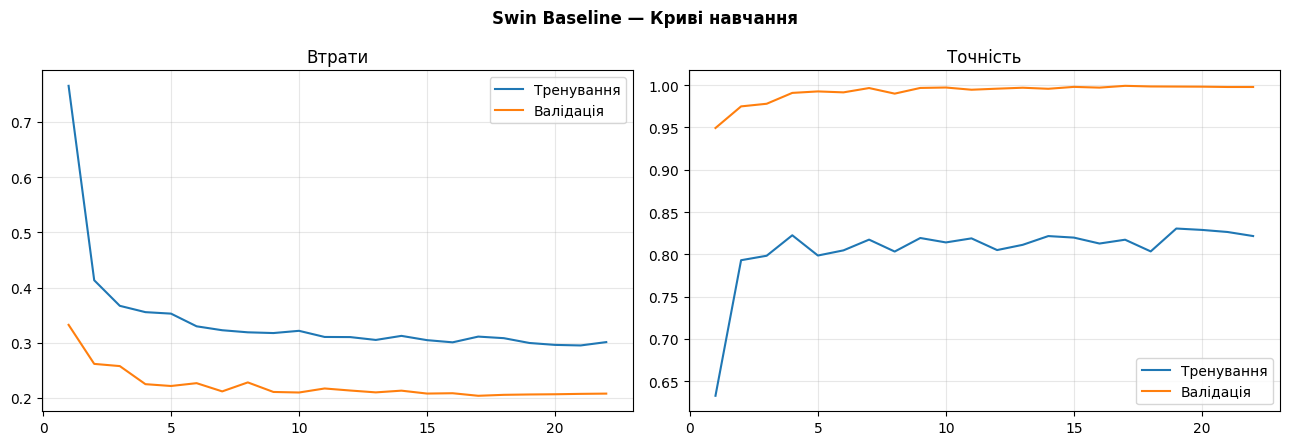

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ep = range(1, len(history["train_loss"]) + 1)

# графік втрат 
axes[0].plot(ep, history["train_loss"], label="Тренування")
axes[0].plot(ep, history["val_loss"], label="Валідація")

axes[0].set_title("Втрати")
axes[0].legend()
axes[0].grid(alpha=0.3)

# графік точності 
axes[1].plot(ep, history["train_acc"], label="Тренування")
axes[1].plot(ep, history["val_acc"], label="Валідація")

axes[1].set_title("Точність")
axes[1].legend()
axes[1].grid(alpha=0.3)


plt.suptitle("Swin Baseline — Криві навчання", fontweight="bold")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "learning_curves.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()

In [ ]:
def print_metrics(y_true, y_pred, split_name):
    print("\n" + "=" * 65)
    print(f"Classification Report — {split_name}")
    print("=" * 65)

    # метрики
    acc = accuracy_score(y_true, y_pred)

    prec_macro = precision_score(
        y_true, y_pred,
        average="macro",
        zero_division=0
    )

    prec_weighted = precision_score(
        y_true, y_pred,
        average="weighted",
        zero_division=0
    )

    rec_macro = recall_score(
        y_true, y_pred,
        average="macro",
        zero_division=0
    )

    rec_weighted = recall_score(
        y_true, y_pred,
        average="weighted",
        zero_division=0
    )

    f1_macro = f1_score(
        y_true, y_pred,
        average="macro",
        zero_division=0
    )

    f1_weighted = f1_score(
        y_true, y_pred,
        average="weighted",
        zero_division=0
    )

    print(f"Accuracy             : {acc:.4f}")
    print(f"Precision (macro)    : {prec_macro:.4f}")
    print(f"Precision (weighted) : {prec_weighted:.4f}")
    print(f"Recall    (macro)    : {rec_macro:.4f}")
    print(f"Recall    (weighted) : {rec_weighted:.4f}")
    print(f"F1        (macro)    : {f1_macro:.4f}")
    print(f"F1        (weighted) : {f1_weighted:.4f}")

    print()

    report = classification_report(
        y_true,
        y_pred,
        target_names=CLASS_LABELS,
        digits=4,
        zero_division=0
    )

    print(report)

In [ ]:
def plot_cm(y_true, y_pred, title, save_name):
    # матриця плутанини
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_LABELS,
        yticklabels=CLASS_LABELS,
        linewidths=0.5,
        cbar=False,
        ax=ax
    )

    ax.set_xlabel("Передбачений клас")
    ax.set_ylabel("Справжній клас")
    ax.set_title(title, fontweight="bold")

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / save_name,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

eval:   0%|          | 0/251 [00:00<?, ?it/s]


Classification Report — Test Dataset
Accuracy             : 0.9993
Precision (macro)    : 0.9992
Precision (weighted) : 0.9993
Recall    (macro)    : 0.9992
Recall    (weighted) : 0.9993
F1        (macro)    : 0.9992
F1        (weighted) : 0.9993

              precision    recall  f1-score   support

      glioma     0.9989    1.0000    0.9995      1886
  meningioma     1.0000    0.9968    0.9984      1879
     notumor     0.9996    1.0000    0.9998      2317
   pituitary     0.9985    1.0000    0.9992      1938

    accuracy                         0.9993      8020
   macro avg     0.9992    0.9992    0.9992      8020
weighted avg     0.9993    0.9993    0.9993      8020



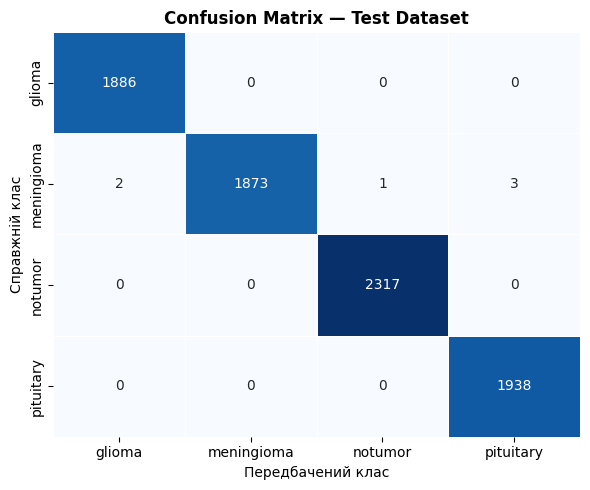

In [ ]:
# оцінюємо модель на тестовому наборі
_, _, test_preds, test_labels, _ = evaluate(
    model,
    test_loader,
    criterion
)

print_metrics(
    test_labels,
    test_preds,
    "Test Dataset"
)

plot_cm(
    test_labels,
    test_preds,
    title="Confusion Matrix — Test Dataset",
    save_name="cm_test.png"
)

In [ ]:
@torch.no_grad()
def eval_tta(model, paths, labels, n_tta=5):
    # TTA трансформації
    tta_tfms = [
        val_transform,

        transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.RandomHorizontalFlip(p=1.0),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ]),

        transforms.Compose([
            transforms.Resize(232),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ]),

        transforms.Compose([
            transforms.Resize(248),
            transforms.CenterCrop(224),
            transforms.RandomHorizontalFlip(p=1.0),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ]),

        transforms.Compose([
            transforms.Resize(256),
            transforms.RandomCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ]),
    ]

    labels = np.asarray(labels)
    acc_probs = None  # ймовірності

    for tfm in tta_tfms[:n_tta]:
        ds = ImagePathDataset(paths, labels, tfm)
        loader = DataLoader(
            ds,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=2,
            pin_memory=True
        )

        probs = []
        model.eval()

        for imgs, _ in loader:
            imgs = imgs.to(COMPUTE_DEVICE)

            with torch.cuda.amp.autocast(enabled=COMPUTE_DEVICE.type == "cuda"):
                logits = model(imgs)
                p = torch.softmax(logits, 1)

            probs.append(p.cpu().numpy())

        probs = np.vstack(probs)

        # результати TTA
        if acc_probs is None:
            acc_probs = probs
        else:
            acc_probs += probs

    avg_probs = acc_probs / n_tta

    return avg_probs.argmax(1), labels, avg_probs


Classification Report — Test Dataset — TTA
Accuracy             : 0.9995
Precision (macro)    : 0.9995
Precision (weighted) : 0.9995
Recall    (macro)    : 0.9995
Recall    (weighted) : 0.9995
F1        (macro)    : 0.9995
F1        (weighted) : 0.9995

              precision    recall  f1-score   support

      glioma     0.9989    1.0000    0.9995      1886
  meningioma     1.0000    0.9979    0.9989      1879
     notumor     1.0000    1.0000    1.0000      2317
   pituitary     0.9990    1.0000    0.9995      1938

    accuracy                         0.9995      8020
   macro avg     0.9995    0.9995    0.9995      8020
weighted avg     0.9995    0.9995    0.9995      8020



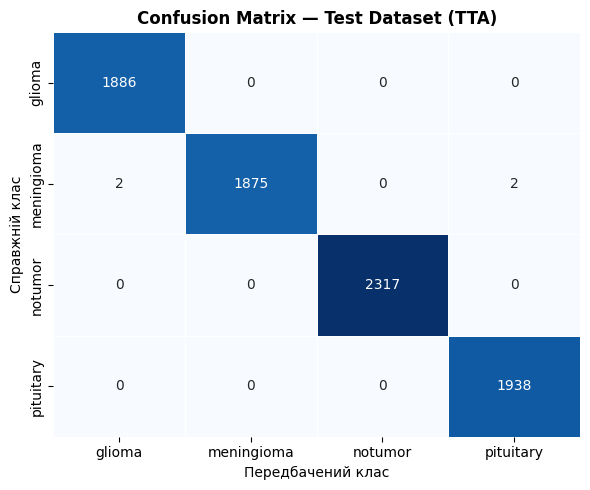

In [ ]:
test_paths_ordered = [Path(s[0]) for s in test_dataset.samples]
test_labels_ordered = np.array([s[1] for s in test_dataset.samples])

# оцінка з використанням TTA
tta_test_preds, tta_test_labels, _ = eval_tta(
    model,
    test_paths_ordered,
    test_labels_ordered,
    n_tta=5
)

print_metrics(
    tta_test_labels,
    tta_test_preds,
    "Test Dataset — TTA"
)

plot_cm(
    tta_test_labels,
    tta_test_preds,
    title="Confusion Matrix — Test Dataset (TTA)",
    save_name="cm_test_tta.png"
)

eval:   0%|          | 0/13 [00:00<?, ?it/s]


Classification Report — External Dataset
Accuracy             : 0.7893
Precision (macro)    : 0.8687
Precision (weighted) : 0.8524
Recall    (macro)    : 0.7749
Recall    (weighted) : 0.7893
F1        (macro)    : 0.7698
F1        (weighted) : 0.7678

              precision    recall  f1-score   support

      glioma     1.0000    0.3700    0.5401       100
  meningioma     0.6461    1.0000    0.7850       115
     notumor     0.8468    1.0000    0.9170       105
   pituitary     0.9818    0.7297    0.8372        74

    accuracy                         0.7893       394
   macro avg     0.8687    0.7749    0.7698       394
weighted avg     0.8524    0.7893    0.7678       394



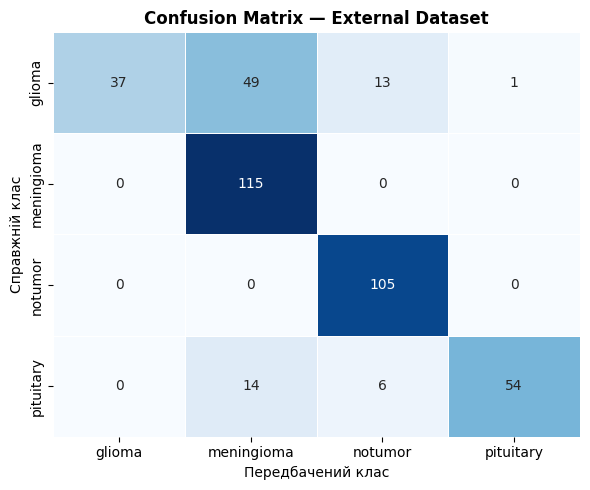

In [ ]:
# оцінка моделі на зовнішньому датасеті
_, _, ext_preds, ext_labels, _ = evaluate(
    model,
    external_loader,
    criterion
)

print_metrics(
    ext_labels,
    ext_preds,
    "External Dataset"
)

plot_cm(
    ext_labels,
    ext_preds,
    title="Confusion Matrix — External Dataset",
    save_name="cm_external.png"
)


Classification Report — External Dataset — TTA
Accuracy             : 0.7919
Precision (macro)    : 0.8696
Precision (weighted) : 0.8535
Recall    (macro)    : 0.7774
Recall    (weighted) : 0.7919
F1        (macro)    : 0.7732
F1        (weighted) : 0.7713

              precision    recall  f1-score   support

      glioma     1.0000    0.3800    0.5507       100
  meningioma     0.6497    1.0000    0.7877       115
     notumor     0.8468    1.0000    0.9170       105
   pituitary     0.9818    0.7297    0.8372        74

    accuracy                         0.7919       394
   macro avg     0.8696    0.7774    0.7732       394
weighted avg     0.8535    0.7919    0.7713       394



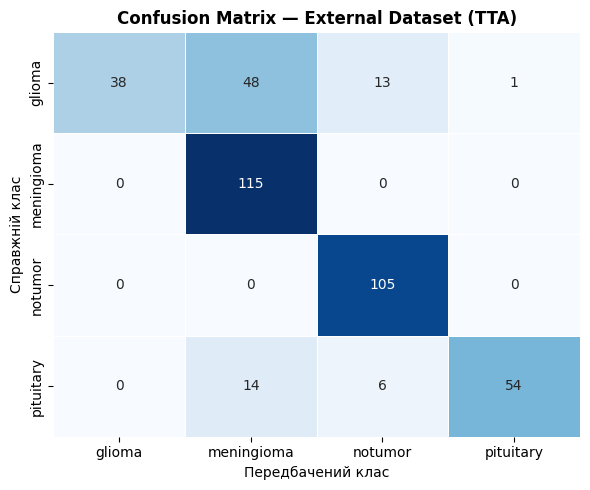

In [ ]:
# оцінка на зовнішньому датасеті з TTA
tta_ext_preds, tta_ext_labels, tta_ext_probs = eval_tta(
    model,
    [str(p) for p in external_paths],
    y_external,
    n_tta=5
)

print_metrics(
    tta_ext_labels,
    tta_ext_preds,
    "External Dataset — TTA"
)

plot_cm(
    tta_ext_labels,
    tta_ext_preds,
    title="Confusion Matrix — External Dataset (TTA)",
    save_name="cm_external_tta.png"
)

In [25]:
!pip -q install scikit-image opencv-python-headless scikit-learn-intelex joblib

In [ ]:
import cv2
import joblib
import time
from joblib import Parallel, delayed
from sklearnex import patch_sklearn
patch_sklearn()
from skimage.feature import hog, local_binary_pattern
from skimage.feature import graycomatrix, graycoprops
from skimage.util import img_as_ubyte
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV
from scipy.stats import loguniform

# параметри HOG-дескриптора
HOG_PIXELS_PER_CELL = (16, 16)
HOG_CELLS_PER_BLOCK = (2, 2)
HOG_ORIENTATIONS = 9

# параметри LBP-дескриптора
LBP_POINTS = 24
LBP_RADIUS = 3.0

N_PARALLEL_JOBS = -1

In [ ]:
# виділення класичних ознак

def extract_hog_features(image: np.ndarray) -> np.ndarray:
    # hog 
    features = hog(
        image,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK,
        block_norm="L2-Hys",
        feature_vector=True,
    )
    return features.astype(np.float32)


def extract_lbp_features(image: np.ndarray) -> np.ndarray:
    # lbp 
    lbp = local_binary_pattern(
        img_as_ubyte(image),
        P=LBP_POINTS,
        R=LBP_RADIUS,
        method="uniform"
    )

    n_bins = LBP_POINTS + 2
    hist, _ = np.histogram(
        lbp.ravel(),
        bins=n_bins,
        range=(0, n_bins),
        density=True
    )

    return hist.astype(np.float32)


def extract_glcm_features(image: np.ndarray) -> np.ndarray:
    # glcm 
    uint8 = img_as_ubyte(image)

    glcm = graycomatrix(
        uint8,
        distances=[1, 3],
        angles=[0, np.pi / 4, np.pi / 2],
        levels=256,
        symmetric=True,
        normed=True
    )

    props = ["contrast", "dissimilarity", "homogeneity", "energy", "correlation"]

    features = [
        graycoprops(glcm, p).ravel()
        for p in props
    ]

    return np.concatenate(features).astype(np.float32)


def extract_classical_no_db4(image_path) -> np.ndarray:
    img_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)

    resized = cv2.resize(
        img_bgr,
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=cv2.INTER_AREA
    )
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0

    # об’єднання всіх ознак
    features = np.concatenate([
        extract_hog_features(gray),
        extract_lbp_features(gray),
        extract_glcm_features(gray),
    ])

    return features.astype(np.float32)

In [ ]:
def load_features(split_name, image_paths, labels_array, cache_file):
    cache_path = OUTPUT_DIR / cache_file

    if cache_path.exists():
        data = joblib.load(cache_path)
        print(f"[{split_name}] З кешу: {data['X'].shape}")
        return data["X"], data["y"]

    print(f"[{split_name}] Виділення ознак для {len(image_paths)} зображень...")

    t0 = time.time()
    feats = Parallel(n_jobs=N_PARALLEL_JOBS, prefer="threads")(
        delayed(extract_classical_no_db4)(p)
        for p in tqdm(image_paths, desc=split_name)
    )

    X = np.vstack(feats)

    joblib.dump({"X": X, "y": labels_array}, cache_path, compress=3)

    print(f"[{split_name}] Готово: {X.shape}, {time.time() - t0:.1f} с")

    return X, labels_array


train_paths = [Path(s[0]) for s in train_dataset.samples]
y_train = np.array([s[1] for s in train_dataset.samples])

test_paths = [Path(s[0]) for s in test_dataset.samples]
y_test_arr = np.array([s[1] for s in test_dataset.samples])


X_cl_train, _ = load_features(
    "train",
    train_paths,
    y_train,
    "cl_train.joblib"
)

X_cl_test, _ = load_features(
    "test",
    test_paths,
    y_test_arr,
    "cl_test.joblib"
)

X_cl_ext, _ = load_features(
    "external",
    external_paths,
    y_external,
    "cl_ext.joblib"
)

print(f"\nРозмірність вектора: {X_cl_train.shape[1]}")

[train] Виділення ознак для 32080 зображень...


train:   0%|          | 0/32080 [00:00<?, ?it/s]

[train] Готово: (32080, 6140), 1050.7 с
[test] Виділення ознак для 8020 зображень...


test:   0%|          | 0/8020 [00:00<?, ?it/s]

[test] Готово: (8020, 6140), 258.2 с
[external] Виділення ознак для 394 зображень...


external:   0%|          | 0/394 [00:00<?, ?it/s]

[external] Готово: (394, 6140), 12.8 с

Розмірність вектора: 6140


In [ ]:
@torch.no_grad()
def extract_swin_embeddings(paths):
    model.eval()  

    ds = ImagePathDataset(
        paths,
        np.zeros(len(paths), dtype=np.int64),
        val_transform
    )

    loader = DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=2,
        pin_memory=True
    )

    embs = []

    for imgs, _ in tqdm(loader, desc="swin", leave=False):
        imgs = imgs.to(COMPUTE_DEVICE)

        with torch.cuda.amp.autocast(enabled=COMPUTE_DEVICE.type == "cuda"):
            feats = model.swin_backbone(imgs)

        embs.append(feats.cpu().numpy())

    return np.vstack(embs)


swin_train = extract_swin_embeddings([str(p) for p in train_paths])
swin_test  = extract_swin_embeddings([str(p) for p in test_paths])
swin_ext   = extract_swin_embeddings([str(p) for p in external_paths])

print(f"Swin embedding dim: {swin_train.shape[1]}")

swin:   0%|          | 0/1003 [00:00<?, ?it/s]

swin:   0%|          | 0/251 [00:00<?, ?it/s]

swin:   0%|          | 0/13 [00:00<?, ?it/s]

Swin embedding dim: 1024


In [ ]:
cl_scaler = StandardScaler()
swin_scaler = StandardScaler()

X_cl_train_scaled = cl_scaler.fit_transform(X_cl_train)
swin_train_scaled = swin_scaler.fit_transform(swin_train)

X_fused_train = np.concatenate(
    [X_cl_train_scaled, swin_train_scaled],
    axis=1
)

X_cl_test_scaled = cl_scaler.transform(X_cl_test)
swin_test_scaled = swin_scaler.transform(swin_test)

X_fused_test = np.concatenate(
    [X_cl_test_scaled, swin_test_scaled],
    axis=1
)

X_cl_ext_scaled = cl_scaler.transform(X_cl_ext)
swin_ext_scaled = swin_scaler.transform(swin_ext)

X_fused_ext = np.concatenate(
    [X_cl_ext_scaled, swin_ext_scaled],
    axis=1
)

print(f"Fusion dim: {X_fused_train.shape[1]}")

Fusion dim: 7164


In [ ]:
# SVM
svm_search = HalvingRandomSearchCV(
    estimator=Pipeline([
        ("scaler", StandardScaler()),

        ("pca", PCA(
            n_components=0.95,
            svd_solver="full",
            random_state=SEED
        )),

        ("svc", SVC(
            kernel="rbf",
            cache_size=2000,
            probability=True,
            random_state=SEED
        )),
    ]),

    factor=3,
    resource="n_samples",
    min_resources=600,
    max_resources=6000,

    n_candidates=40,
    scoring="accuracy",

    cv=StratifiedKFold(
        3,
        shuffle=True,
        random_state=SEED
    ),

    n_jobs=-1,
    random_state=SEED,
    verbose=1,
)

t0 = time.time()
svm_search.fit(X_fused_train, y_train)

svm_model = svm_search.best_estimator_

In [ ]:
# KNN
knn_model = Pipeline([
    ("scaler", StandardScaler()),

    ("pca", PCA(
        n_components=0.95,
        svd_solver="full",
        random_state=SEED
    )),

    ("knn", KNeighborsClassifier(
        n_neighbors=7,
        metric="cosine",
        n_jobs=-1
    )),
])

knn_model.fit(X_fused_train, y_train)

In [ ]:
# передбачення для test і external
svm_test_preds = svm_model.predict(X_fused_test)
knn_test_preds = knn_model.predict(X_fused_test)

svm_ext_preds = svm_model.predict(X_fused_ext)
knn_ext_preds = knn_model.predict(X_fused_ext)

print(f"{'Модель':<35} {'Test Acc':>10} {'Ext Acc':>10}")
print("-" * 70)

rows = [
    (
        "Swin Baseline",
        y_test_arr, test_preds,
        y_external, ext_preds
    ),

    (
        "Swin Baseline TTA",
        tta_test_labels, tta_test_preds,
        tta_ext_labels, tta_ext_preds
    ),

    (
        "SVM Fusion",
        y_test_arr, svm_test_preds,
        y_external, svm_ext_preds
    ),

    (
        "KNN Fusion",
        y_test_arr, knn_test_preds,
        y_external, knn_ext_preds
    ),
]


for name, yt, ytp, ye, yep in rows:
    test_acc = accuracy_score(yt, ytp)
    ext_acc = accuracy_score(ye, yep)

    print(f"{name:<35} {test_acc:>10.4f} {ext_acc:>10.4f}")

Модель                                Test Acc    Ext Acc
----------------------------------------------------------------------
Swin Baseline                           0.9993     0.7893
Swin Baseline TTA                       0.9995     0.7919
SVM Fusion                              0.9991     0.8046
KNN Fusion                              0.9990     0.7792


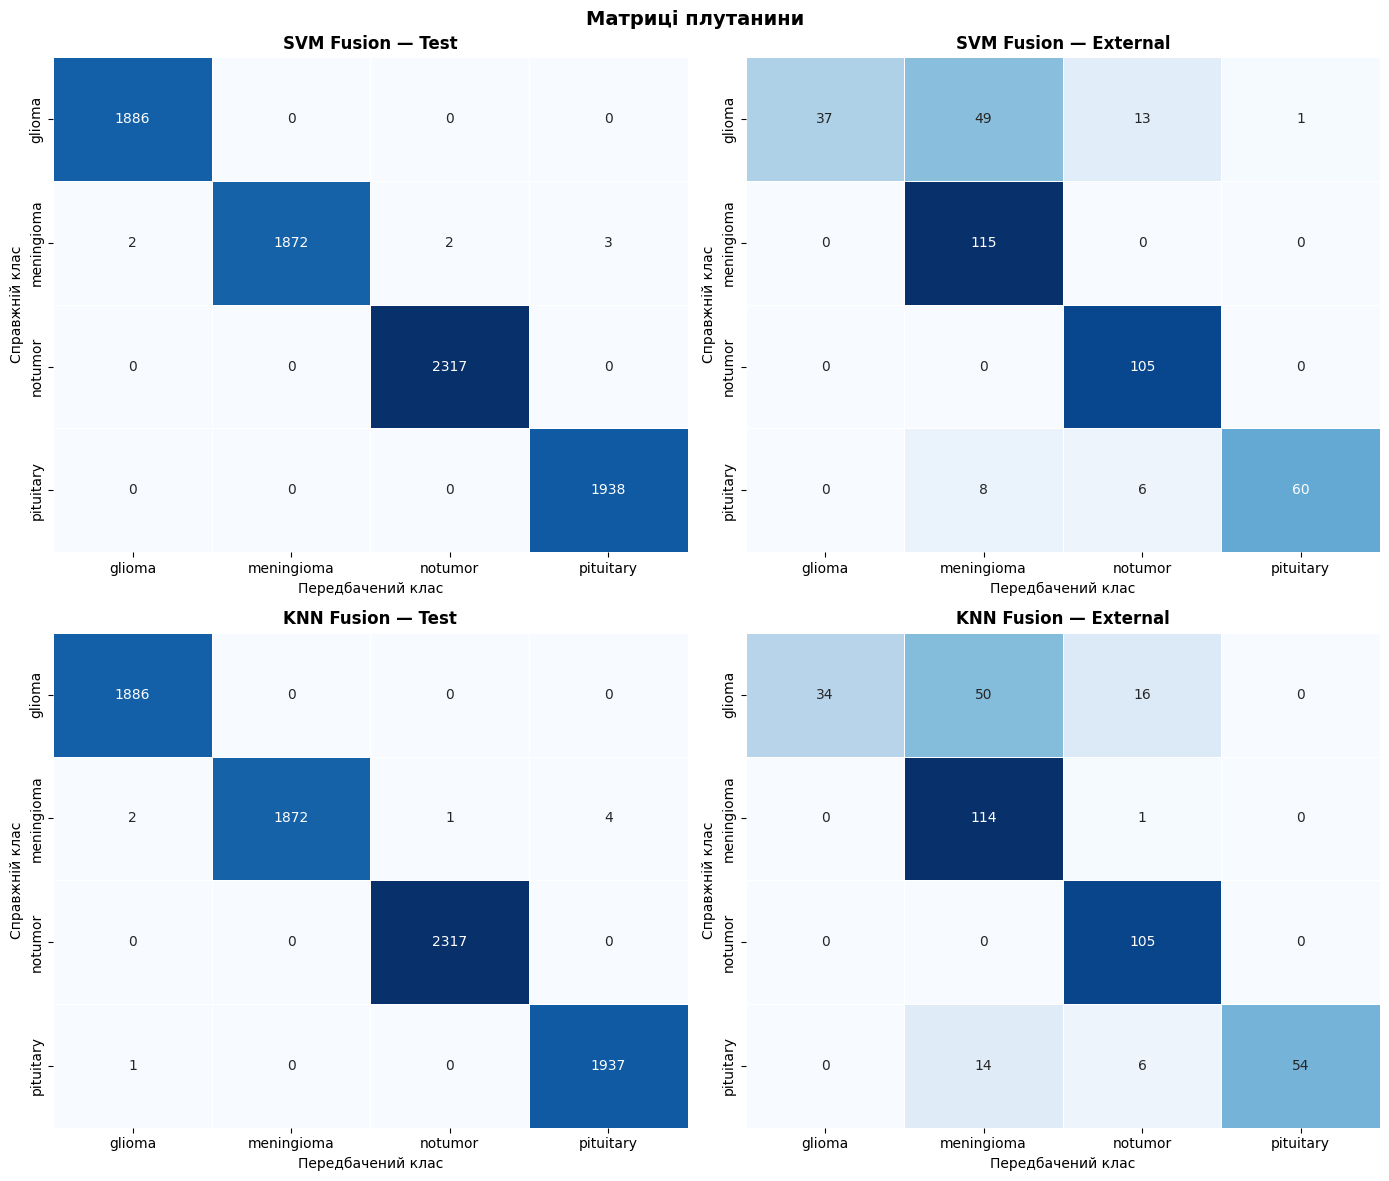

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

pairs = [
    (y_test_arr, svm_test_preds, "SVM Fusion — Test"),
    (y_external, svm_ext_preds,  "SVM Fusion — External"),
    (y_test_arr, knn_test_preds, "KNN Fusion — Test"),
    (y_external, knn_ext_preds,  "KNN Fusion — External"),
]

for ax, (y_true, y_pred, title) in zip(axes.ravel(), pairs):
    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_LABELS,
        yticklabels=CLASS_LABELS,
        linewidths=0.5,
        cbar=False,
        ax=ax
    )

    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Передбачений клас")
    ax.set_ylabel("Справжній клас")

plt.suptitle("Матриці плутанини", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "cm_fusion.png",
    dpi=150,
    bbox_inches="tight"
)
plt.show()